# Stage 3: NLOS Bounce Distance Prediction (No FP v3)
## Multi-Model Pipeline — bounce_path_idx Estimation via LNN Embeddings

**Purpose**: Given an NLOS signal where the single-bounce path is identifiable (Stage 2 = Correctable), predict the **bounce path CIR index** (`bounce_path_idx`), then convert to `d_bounce` via physics formula.

**Target**: `bounce_path_idx = fp_idx + (d_bounce − d_hardware) / 0.3003` — per-sample continuous CIR index

**Inverse**: `d_bounce = d_hardware + (predicted_bpi − fp_idx) × 0.3003` — convert back to meters

**Why not predict d_bounce directly?** d_bounce is constant per scenario (e.g. 9.54, 16.09) — regressing a constant is just classification. bounce_path_idx varies per sample (fp_idx, d_hardware differ) → real regression.

**Data**: Combined dataset correctable NLOS only (9.54m + 16.09m)
- 16.80m excluded — all multi-bounce (no correctable samples)
- 70/30 train/holdout split

**Features** (66 total):
- 64-dim LNN embeddings (frozen Stage 1 encoder — CIR shape representation)
- `fp_idx` — first path index
- `d_hardware` — hardware-reported distance

**Architecture**: Frozen DualCircuit_PI_HLNN_NoFP encoder (v3) → **66 features** → Random Forest Regressor

**Evaluation flow**:
- Stage 1: Train + validate LOS/NLOS (holdout + OOD) ✓
- Stage 2: Train + validate correctable classifier (holdout + OOD) ✓
- **Stage 3: Train + validate bounce distance (holdout)**
- test_pipeline: Chain all 3 stages end-to-end

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy.signal import find_peaks
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os

# ==========================================
# CONFIGURATION
# ==========================================
M_PER_IDX = 0.3003
DIST_PER_IDX = 0.3002

CONFIG = {
    # ROI alignment (same as Stage 1/2)
    "search_start": 740,
    "search_end": 810,
    # Peak detection — morphological CIR quality (same as Stage 2)
    "peak_prominence": 0.20,
    "peak_min_distance": 5,
    "dominant_path_max_peaks": 2,
    # Geometric bounce dominance (same as Stage 2)
    "bounce_search_window": 3,
    "dominance_threshold": 0.50,
    # Random Forest Regressor
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    # Split
    "test_ratio": 0.30,
    "seed": 42,
}

np.random.seed(CONFIG["seed"])
print(f"Config: {CONFIG}")
print(f"\nTarget: bounce_path_idx = fp_idx + (d_bounce - d_hardware) / {M_PER_IDX}")
print(f"Inverse: d_bounce = d_hardware + (pred_bpi - fp_idx) × {M_PER_IDX}")
print(f"Filter: correctable only (bounce dominance >= {CONFIG['dominance_threshold']:.0%} AND num_peaks <= {CONFIG['dominant_path_max_peaks']})")
print(f"Model: 64-dim LNN embeddings + fp_idx + d_hardware → RF Regressor ({CONFIG['n_estimators']} trees)")

Config: {'search_start': 740, 'search_end': 810, 'peak_prominence': 0.2, 'peak_min_distance': 5, 'dominant_path_max_peaks': 2, 'bounce_search_window': 3, 'dominance_threshold': 0.5, 'n_estimators': 200, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2, 'test_ratio': 0.3, 'seed': 42}

Target: bounce_path_idx = fp_idx + (d_bounce - d_hardware) / 0.3003
Inverse: d_bounce = d_hardware + (pred_bpi - fp_idx) × 0.3003
Filter: correctable only (bounce dominance >= 50% AND num_peaks <= 2)
Model: 64-dim LNN embeddings + fp_idx + d_hardware → RF Regressor (200 trees)


---
## Section 2: Data Loading & Correctable Filtering

1. Load NLOS samples from combined dataset (9.54m + 16.09m)
2. Filter to correctable samples (bounce dominance ≥ threshold AND ≤ 2 peaks)
3. Compute `bounce_path_idx` per sample

In [43]:
# ==========================================
# ROI ALIGNMENT (reused from Stage 1/2)
# ==========================================
def get_roi_alignment(sig, search_start=CONFIG["search_start"],
                      search_end=CONFIG["search_end"]):
    """Find leading edge by backtracking from peak."""
    region = sig[search_start:search_end]
    if len(region) == 0:
        return np.argmax(sig)

    peak_local = np.argmax(region)
    peak_idx = search_start + peak_local
    peak_val = sig[peak_idx]

    noise_section = sig[:search_start]
    if len(noise_section) > 10:
        noise_mean = np.mean(noise_section)
        noise_std = np.std(noise_section)
        threshold = max(noise_mean + 3 * noise_std, 0.05 * peak_val)
    else:
        threshold = 0.05 * peak_val

    leading_edge = peak_idx
    for i in range(peak_idx, max(search_start - 20, 0), -1):
        if sig[i] < threshold:
            leading_edge = i + 1
            break

    return leading_edge


# ==========================================
# HELPER: extract arrays from a filtered DataFrame
# ==========================================
def _extract_arrays(corr_df, cir_cols):
    """Extract signal arrays, fp_idx, d_hardware, and metadata from correctable DataFrame."""
    rxpacc_col = 'RXPACC' if 'RXPACC' in corr_df.columns else 'RX_PACC'

    raw_sigs, leading_edges = [], []
    d_hardware_list, d_direct_list, d_bounce_list, source_files = [], [], [], []
    fp_idx_list = []

    for _, row in corr_df.iterrows():
        sig = pd.to_numeric(row[cir_cols], errors='coerce').fillna(0).astype(float).values
        rxpacc = float(row.get(rxpacc_col, 128.0))
        if rxpacc > 0:
            sig = sig / rxpacc

        le = get_roi_alignment(sig)
        raw_sigs.append(sig)
        leading_edges.append(le)

        d_hardware_list.append(float(row['Distance']))
        d_direct_list.append(float(row['d_direct']))
        d_bounce_list.append(float(row['d_bounce']))
        source_files.append(str(row.get('Source_File', '')))

        # fp_idx
        fp_i = float(row.get('fp_idx', row.get('FP_INDEX', 0)))
        if 'fp_idx' not in corr_df.columns and 'FP_INDEX' in corr_df.columns:
            fp_i = float(row['FP_INDEX']) / 64.0
        fp_idx_list.append(fp_i)

    leading_edges = np.array(leading_edges)
    d_hardware = np.array(d_hardware_list, dtype=float)
    d_direct   = np.array(d_direct_list,   dtype=float)
    d_bounce   = np.array(d_bounce_list,   dtype=float)
    fp_idx     = np.array(fp_idx_list,     dtype=float)

    # Compute bounce_path_idx (per-sample continuous target)
    bounce_path_idx = fp_idx + (d_bounce - d_hardware) / M_PER_IDX

    groups = []
    for sf in source_files:
        match = re.search(r'([\d.]+)m_nlos', sf)
        groups.append(match.group(1) + 'm' if match else 'unknown')
    groups = np.array(groups)

    return np.array(raw_sigs), leading_edges, d_hardware, d_direct, d_bounce, fp_idx, bounce_path_idx, groups


# ==========================================
# LOAD COMBINED DATASET (9.54m + 16.09m correctable)
# ==========================================
def load_correctable_combined(filepath="../dataset/channels/combined_uwb_dataset.csv"):
    print(f"Loading combined: {filepath}")
    df = pd.read_csv(filepath)
    cir_cols = sorted([c for c in df.columns if c.startswith('CIR')],
                      key=lambda x: int(x.replace('CIR', '')))
    corr_df = df[(df["Label"] == 1) & (df["is_correctable"] == 1)].reset_index(drop=True)
    total_nlos = (df["Label"] == 1).sum()
    print(f"  NLOS: {total_nlos}, Correctable: {len(corr_df)} ({100*len(corr_df)/total_nlos:.1f}%)")
    return _extract_arrays(corr_df, cir_cols)


# ==========================================
# LOAD DATA
# ==========================================
(raw_sigs, leading_edges, d_hardware, d_direct, d_bounce,
 fp_idx, bounce_path_idx, groups) = load_correctable_combined()

print(f"\n{'='*50}")
print(f"Combined correctable: {len(d_bounce)} samples")
print(f"  Target: bounce_path_idx (per-sample continuous CIR index)")
print(f"  bpi range: [{bounce_path_idx.min():.2f}, {bounce_path_idx.max():.2f}], "
      f"mean={bounce_path_idx.mean():.2f}, std={bounce_path_idx.std():.2f}")
for g in sorted(set(groups)):
    mask = groups == g
    print(f"  {g}: n={int(mask.sum())}, d_bounce={d_bounce[mask].mean():.2f}m, "
          f"bpi={bounce_path_idx[mask].mean():.2f}±{bounce_path_idx[mask].std():.2f}")

Loading combined: ../dataset/channels/combined_uwb_dataset.csv
  NLOS: 1800, Correctable: 506 (28.1%)

Combined correctable: 506 samples
  Target: bounce_path_idx (per-sample continuous CIR index)
  bpi range: [743.36, 779.23], mean=766.21, std=10.81
  16.09m: n=457, d_bounce=16.09m, bpi=767.89±9.98
  9.54m: n=49, d_bounce=9.54m, bpi=750.53±2.35


---
## Section 3: Target Visualization

Visualize the `bounce_path_idx` distribution for correctable samples. Unlike `d_bounce` (constant per scenario), `bounce_path_idx` varies per sample due to different `fp_idx` and `d_hardware`.

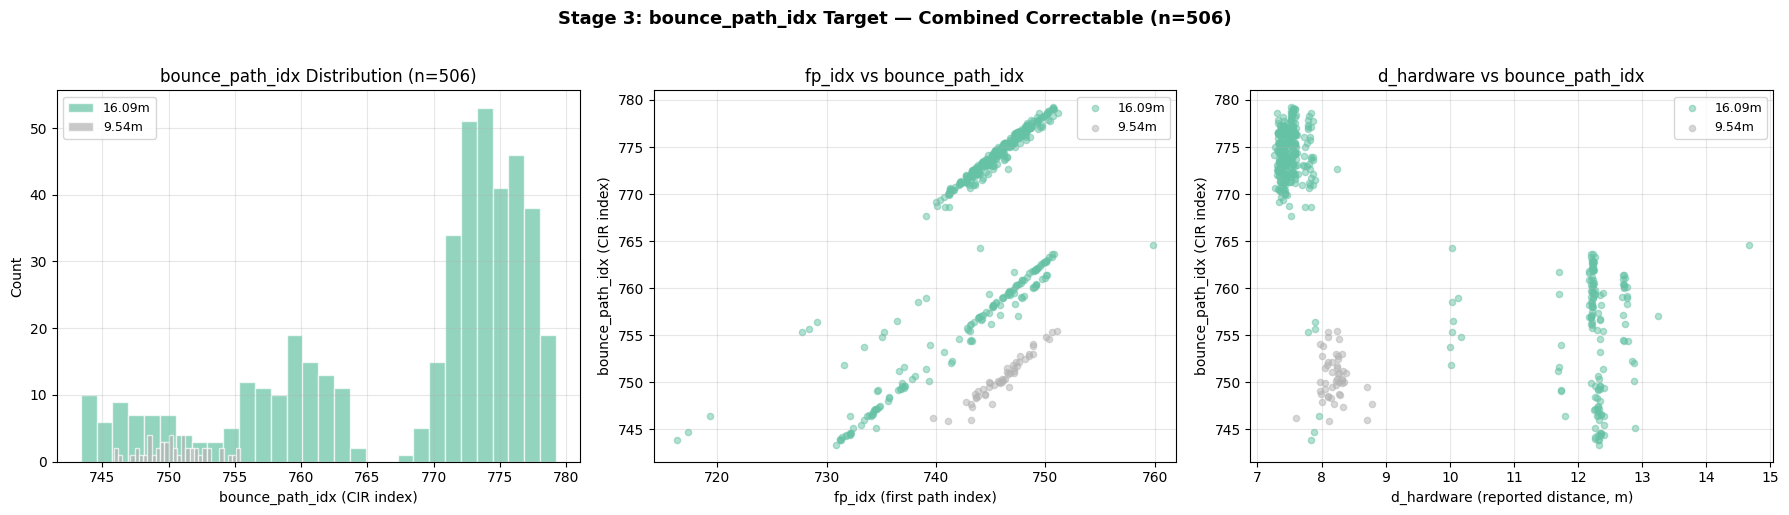

In [44]:
# ==========================================
# TARGET VISUALIZATION — bounce_path_idx
# ==========================================
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(wspace=0.3)

unique_groups = sorted(set(groups))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_groups)))
group_colors = {g: colors[i] for i, g in enumerate(unique_groups)}

# 1. bounce_path_idx histogram
ax = axs[0]
for g in unique_groups:
    mask = groups == g
    ax.hist(bounce_path_idx[mask], bins=30, alpha=0.7, label=g, color=group_colors[g], edgecolor='white')
ax.set_xlabel('bounce_path_idx (CIR index)')
ax.set_ylabel('Count')
ax.set_title(f'bounce_path_idx Distribution (n={len(bounce_path_idx)})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. fp_idx vs bounce_path_idx
ax = axs[1]
for g in unique_groups:
    mask = groups == g
    ax.scatter(fp_idx[mask], bounce_path_idx[mask],
               c=[group_colors[g]], s=20, alpha=0.5, label=g)
ax.set_xlabel('fp_idx (first path index)')
ax.set_ylabel('bounce_path_idx (CIR index)')
ax.set_title('fp_idx vs bounce_path_idx')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 3. d_hardware vs bounce_path_idx
ax = axs[2]
for g in unique_groups:
    mask = groups == g
    ax.scatter(d_hardware[mask], bounce_path_idx[mask],
               c=[group_colors[g]], s=20, alpha=0.5, label=g)
ax.set_xlabel('d_hardware (reported distance, m)')
ax.set_ylabel('bounce_path_idx (CIR index)')
ax.set_title('d_hardware vs bounce_path_idx')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Stage 3: bounce_path_idx Target — Combined Correctable (n={len(bounce_path_idx)})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 4: Frozen LNN Encoder — Embedding Extraction

Same frozen DualCircuit_PI_HLNN_NoFP encoder as Stage 1/2 (v3). Extracts 64-dim time-averaged embeddings for combined correctable NLOS samples.

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class PILiquidCell(nn.Module):
    """
    Conductance-based LTC cell (Hasani et al. 2020).
    Identical to Stage 1/2 — no changes.
    """
    def __init__(self, input_size, hidden_size, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_size  = input_size
        self.ode_unfolds = ode_unfolds

        self.gleak = nn.Parameter(torch.empty(hidden_size).uniform_(0.001, 1.0))
        self.vleak = nn.Parameter(torch.empty(hidden_size).uniform_(-0.2, 0.2))
        self.cm    = nn.Parameter(torch.empty(hidden_size).uniform_(0.4, 0.6))

        self.w     = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.001, 1.0))
        self.erev  = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-0.2, 0.2))
        self.mu    = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(0.3, 0.8))
        self.sigma = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(3, 8))

        self.sensory_w     = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.001, 1.0))
        self.sensory_mu    = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(0.3, 0.8))
        self.sensory_sigma = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(3, 8))

    def forward(self, x_t, h_prev, dt=1.0):
        gleak     = F.softplus(self.gleak)
        cm        = F.softplus(self.cm)
        w         = F.softplus(self.w)
        sensory_w = F.softplus(self.sensory_w)

        sensory_gate    = torch.sigmoid(self.sensory_sigma * (x_t.unsqueeze(-1) - self.sensory_mu))
        sensory_current = (sensory_w * sensory_gate * x_t.unsqueeze(-1)).sum(dim=1)

        cm_t = cm / (dt / self.ode_unfolds)
        v    = h_prev

        for _ in range(self.ode_unfolds):
            recurrent_gate = torch.sigmoid(self.sigma.unsqueeze(0) * (v.unsqueeze(2) - self.mu.unsqueeze(0)))
            w_gate = w.unsqueeze(0) * recurrent_gate
            w_num  = (w_gate * self.erev.unsqueeze(0)).sum(dim=1)
            w_den  = w_gate.sum(dim=1)
            numerator   = cm_t * v + gleak * self.vleak + w_num + sensory_current
            denominator = cm_t + gleak + w_den + 1e-8
            v = numerator / denominator
            v = torch.clamp(v, -1.0, 1.0)

        tau = cm / (gleak + w_den + 1e-8)
        return v, tau


class DualCircuit_PI_HLNN_NoFP(nn.Module):
    """
    Dual-circuit PI-HLNN WITHOUT FP_AMPL conditioning (v3).
    Both circuits always start from h₀ = zeros(32).
    Uses average pooling (matching the original PI-HLNN).
    """
    def __init__(self, input_size=1, hidden_size=32, dropout=0.2, ode_unfolds=6):
        super().__init__()
        self.hidden_size = hidden_size

        self.cell_los  = PILiquidCell(input_size, hidden_size, ode_unfolds)
        self.cell_nlos = PILiquidCell(input_size, hidden_size, ode_unfolds)

        self.P_nlos2los = nn.Linear(hidden_size, hidden_size, bias=False)
        self.P_los2nlos = nn.Linear(hidden_size, hidden_size, bias=False)

        self.gate_los  = nn.Linear(hidden_size * 2, hidden_size)
        self.gate_nlos = nn.Linear(hidden_size * 2, hidden_size)

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def _run_circuits(self, x_seq):
        batch_size, seq_len, _ = x_seq.size()

        h_los  = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)
        h_nlos = torch.zeros(batch_size, self.hidden_size, device=x_seq.device)

        los_states, nlos_states = [], []
        tau_los_sum  = torch.zeros_like(h_los)
        tau_nlos_sum = torch.zeros_like(h_nlos)

        for t in range(seq_len):
            x_t = x_seq[:, t, :]

            proj_nlos_to_los = self.P_nlos2los(h_nlos)
            proj_los_to_nlos = self.P_los2nlos(h_los)

            g_los  = torch.sigmoid(self.gate_los( torch.cat([h_los,  proj_nlos_to_los], dim=1)))
            g_nlos = torch.sigmoid(self.gate_nlos(torch.cat([h_nlos, proj_los_to_nlos], dim=1)))

            h_los_in  = h_los  + g_los  * proj_nlos_to_los
            h_nlos_in = h_nlos + g_nlos * proj_los_to_nlos

            h_los,  tau_los  = self.cell_los( x_t, h_los_in)
            h_nlos, tau_nlos = self.cell_nlos(x_t, h_nlos_in)

            los_states.append(h_los.unsqueeze(1))
            nlos_states.append(h_nlos.unsqueeze(1))
            tau_los_sum  += tau_los
            tau_nlos_sum += tau_nlos

        los_all  = torch.cat(los_states,  dim=1)
        nlos_all = torch.cat(nlos_states, dim=1)
        tau_los_mean  = tau_los_sum  / seq_len
        tau_nlos_mean = tau_nlos_sum / seq_len
        return los_all, nlos_all, tau_los_mean, tau_nlos_mean

    def _pool_and_fuse(self, los_all, nlos_all):
        h_los_avg  = los_all.mean(dim=1)
        h_nlos_avg = nlos_all.mean(dim=1)
        return torch.cat([h_los_avg, h_nlos_avg], dim=1)

    def forward(self, x_seq):
        los_all, nlos_all, tau_los_mean, tau_nlos_mean = self._run_circuits(x_seq)
        h_fused = self._pool_and_fuse(los_all, nlos_all)
        pred = self.classifier(h_fused)
        return pred, tau_los_mean, tau_nlos_mean

    def embed(self, x_seq):
        """Return 64-dim fused embedding for Stage 2/3."""
        los_all, nlos_all, _, _ = self._run_circuits(x_seq)
        return self._pool_and_fuse(los_all, nlos_all)


print(f"DualCircuit_PI_HLNN_NoFP defined: {sum(p.numel() for p in DualCircuit_PI_HLNN_NoFP().parameters()):,} params")
print(f"  Embedding dim: 64 (2 x 32)")
print(f"  Pooling: average-over-time (no attention — time-averaged ODE trajectory)")
print(f"  FP_AMPL conditioning: NONE (zero-init h₀)")

DualCircuit_PI_HLNN_NoFP defined: 16,897 params
  Embedding dim: 64 (2 x 32)
  Pooling: average-over-time (no attention — time-averaged ODE trajectory)
  FP_AMPL conditioning: NONE (zero-init h₀)


In [46]:
# ==========================================
# LOAD FROZEN STAGE 1 v3 ENCODER & EXTRACT EMBEDDINGS
# ==========================================
_saved = torch.load("stage1_pi_hlnn_no_fp_v3_config.pt", map_location="cpu", weights_only=False)
STAGE1_CONFIG = _saved["config"]
print("STAGE1_CONFIG loaded from stage1_pi_hlnn_no_fp_v3_config.pt")

EMBEDDING_DIM = STAGE1_CONFIG['hidden_size'] * 2  # 64
EMBEDDING_NAMES = [f'LNN_h{i}' for i in range(EMBEDDING_DIM)]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def preprocess_cir_for_lnn(sig, leading_edge):
    """Convert a single RXPACC-normalized CIR + leading edge to 60-sample window."""
    PRE = STAGE1_CONFIG['pre_crop']
    TOTAL = STAGE1_CONFIG['total_len']
    start = max(0, leading_edge - PRE)
    end = start + TOTAL
    if end > len(sig):
        end = len(sig)
        start = max(0, end - TOTAL)
    crop = sig[start:end]
    if len(crop) < TOTAL:
        crop = np.pad(crop, (0, TOTAL - len(crop)), mode='constant')
    local_min, local_max = np.min(crop), np.max(crop)
    rng = local_max - local_min
    crop = (crop - local_min) / rng if rng > 0 else np.zeros(TOTAL)
    return crop


def extract_embeddings(sigs, les, encoder, batch_size=256):
    """Extract 64-dim LNN embeddings for a set of CIR signals."""
    cir_seqs = [preprocess_cir_for_lnn(sigs[i], les[i]) for i in range(len(sigs))]
    cir_tensor = torch.tensor(
        np.array(cir_seqs).reshape(-1, STAGE1_CONFIG['total_len'], 1),
        dtype=torch.float32
    ).to(device)
    all_emb = []
    with torch.no_grad():
        for i in range(0, len(cir_tensor), batch_size):
            emb = encoder.embed(cir_tensor[i:i+batch_size])
            all_emb.append(emb.cpu().numpy())
    return np.vstack(all_emb)


# Load frozen encoder
lnn_encoder = DualCircuit_PI_HLNN_NoFP(
    input_size=STAGE1_CONFIG['input_size'],
    hidden_size=STAGE1_CONFIG['hidden_size'],
    dropout=STAGE1_CONFIG['dropout'],
    ode_unfolds=STAGE1_CONFIG['ode_unfolds'],
).to(device)

checkpoint_path = 'stage1_pi_hlnn_no_fp_v3_best.pt'
lnn_encoder.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
lnn_encoder.eval()
for param in lnn_encoder.parameters():
    param.requires_grad = False

print(f"Loaded frozen encoder from {checkpoint_path} ({device})")
print(f"  {sum(p.numel() for p in lnn_encoder.parameters()):,} params (all frozen), embedding dim: {EMBEDDING_DIM}")

# Extract embeddings
print(f"\nExtracting {EMBEDDING_DIM}-dim embeddings for {len(raw_sigs)} samples...")
embeddings = extract_embeddings(raw_sigs, leading_edges, lnn_encoder)
print(f"  Shape: {embeddings.shape}, mean: {embeddings.mean():.4f}, std: {embeddings.std():.4f}")

STAGE1_CONFIG loaded from stage1_pi_hlnn_no_fp_v3_config.pt
Loaded frozen encoder from stage1_pi_hlnn_no_fp_v3_best.pt (cuda)
  16,897 params (all frozen), embedding dim: 64

Extracting 64-dim embeddings for 506 samples...
  Shape: (506, 64), mean: -0.0295, std: 0.1005


---
## Section 5: Train + Holdout Test

**Train**: 70% of combined correctable (9.54m + 16.09m) — 66 features (64 LNN + fp_idx + d_hw)
**Holdout test**: 30% of combined correctable

In [47]:
# ==========================================
# TRAIN ON COMBINED → HOLDOUT TEST
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# ── Features: 64 LNN + fp_idx + d_hardware ──
X_all = np.hstack([embeddings, fp_idx.reshape(-1, 1), d_hardware.reshape(-1, 1)])
y_all = bounce_path_idx

FEATURE_DIM = X_all.shape[1]
FEATURE_NAMES = EMBEDDING_NAMES + ['fp_idx', 'd_hardware']
print(f"Features: {FEATURE_DIM} (64 LNN + fp_idx + d_hardware)")
print(f"Samples: {len(X_all)} combined correctable (9.54m + 16.09m)")

# ── 70/30 stratified split ──
X_train, X_test, y_train, y_test, g_train, g_test, \
    dhw_train, dhw_test, fpi_train, fpi_test, db_train, db_test = train_test_split(
    X_all, y_all, groups, d_hardware, fp_idx, d_bounce,
    test_size=CONFIG["test_ratio"],
    stratify=groups,
    random_state=CONFIG["seed"]
)

print(f"\nTrain: {len(X_train)}, Holdout: {len(X_test)}")
for g in sorted(set(g_train)):
    n_tr = int((g_train == g).sum())
    n_te = int((g_test == g).sum())
    print(f"  {g}: train={n_tr}, holdout={n_te}")

# Inverse-frequency sample weights
unique_groups, group_counts = np.unique(g_train, return_counts=True)
group_weight_map = {g: len(g_train) / (len(unique_groups) * c)
                    for g, c in zip(unique_groups, group_counts)}
sample_weights = np.array([group_weight_map[g] for g in g_train])

# ── Train RF Regressor ──
pred_model = RandomForestRegressor(
    n_estimators=CONFIG["n_estimators"],
    max_depth=CONFIG["max_depth"],
    min_samples_split=CONFIG["min_samples_split"],
    min_samples_leaf=CONFIG["min_samples_leaf"],
    random_state=CONFIG["seed"],
    n_jobs=-1,
)
pred_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_train = pred_model.predict(X_train)
y_pred_test  = pred_model.predict(X_test)

# ── bounce_path_idx metrics ──
train_bpi_mae = mean_absolute_error(y_train, y_pred_train)
test_bpi_mae  = mean_absolute_error(y_test, y_pred_test)
test_bpi_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_bpi_r2   = r2_score(y_test, y_pred_test)

print(f"\n--- bounce_path_idx metrics ---")
print(f"Train MAE:  {train_bpi_mae:.4f} idx ({train_bpi_mae * M_PER_IDX:.4f}m)")
print(f"Test MAE:   {test_bpi_mae:.4f} idx ({test_bpi_mae * M_PER_IDX:.4f}m)")
print(f"Test RMSE:  {test_bpi_rmse:.4f} idx ({test_bpi_rmse * M_PER_IDX:.4f}m)")
print(f"Test R²:    {test_bpi_r2:.4f}")

# ── Inverse conversion: d_bounce = d_hardware + (pred_bpi - fp_idx) × M_PER_IDX ──
pred_d_bounce = dhw_test + (y_pred_test - fpi_test) * M_PER_IDX

test_mae  = mean_absolute_error(db_test, pred_d_bounce)
test_rmse = np.sqrt(mean_squared_error(db_test, pred_d_bounce))
test_r2   = r2_score(db_test, pred_d_bounce)

print(f"\n--- d_bounce metrics (after inverse conversion) ---")
print(f"Test MAE:   {test_mae:.4f}m")
print(f"Test RMSE:  {test_rmse:.4f}m")
print(f"Test R²:    {test_r2:.4f}")

print(f"\nPer-scenario holdout MAE:")
for g in sorted(set(g_test)):
    mask = g_test == g
    bpi_g = mean_absolute_error(y_test[mask], y_pred_test[mask])
    db_g  = mean_absolute_error(db_test[mask], pred_d_bounce[mask])
    print(f"  {g}: bpi MAE={bpi_g:.4f} idx, d_bounce MAE={db_g:.4f}m (n={int(mask.sum())})")

# Feature importance — top 10
importances = pred_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]
print(f"\nTop 10 feature importances:")
for i in top_idx:
    print(f"  {FEATURE_NAMES[i]:<20s} {importances[i]:.4f}")

Features: 66 (64 LNN + fp_idx + d_hardware)
Samples: 506 combined correctable (9.54m + 16.09m)

Train: 354, Holdout: 152
  16.09m: train=320, holdout=137
  9.54m: train=34, holdout=15

--- bounce_path_idx metrics ---
Train MAE:  0.4038 idx (0.1213m)
Test MAE:   0.8185 idx (0.2458m)
Test RMSE:  2.1207 idx (0.6369m)
Test R²:    0.9599

--- d_bounce metrics (after inverse conversion) ---
Test MAE:   0.2458m
Test RMSE:  0.6369m
Test R²:    0.8937

Per-scenario holdout MAE:
  16.09m: bpi MAE=0.8451 idx, d_bounce MAE=0.2538m (n=137)
  9.54m: bpi MAE=0.5756 idx, d_bounce MAE=0.1728m (n=15)

Top 10 feature importances:
  d_hardware           0.8170
  fp_idx               0.0921
  LNN_h24              0.0261
  LNN_h46              0.0170
  LNN_h47              0.0066
  LNN_h39              0.0045
  LNN_h15              0.0031
  LNN_h23              0.0028
  LNN_h6               0.0024
  LNN_h20              0.0021


---
## Section 6: Diagnostics

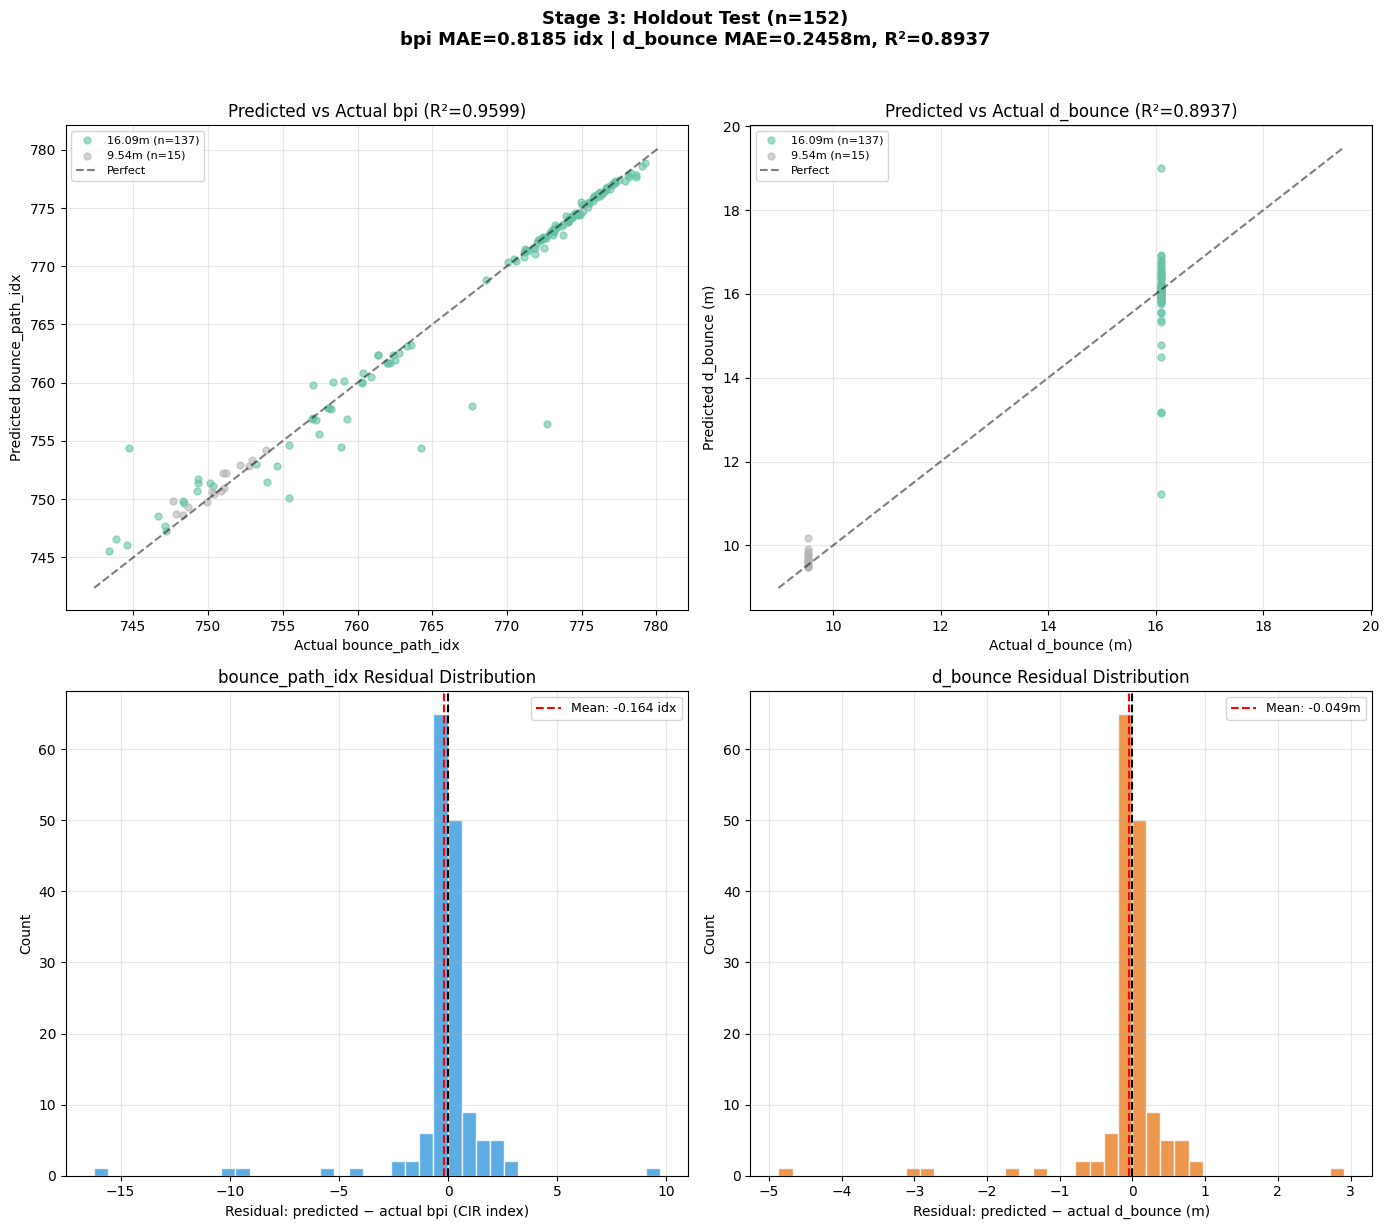


Prediction accuracy within tolerance (d_bounce):
  Tolerance     Correct    Total   Accuracy
  ------------------------------------------
  ±0.25m            120      152      78.9%
  ±0.50m            134      152      88.2%
  ±1.00m            146      152      96.1%
  ±1.50m            147      152      96.7%

Per-scenario breakdown (±0.50m):
  16.09m: 120/137 correct (87.6%)
  9.54m: 14/15 correct (93.3%)


In [48]:
# ==========================================
# DIAGNOSTICS — Holdout Test
# ==========================================
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

unique_test_groups = sorted(set(g_test))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_test_groups)))
group_colors = {g: colors[i] for i, g in enumerate(unique_test_groups)}

# 1. Predicted vs Actual bounce_path_idx
ax = axs[0, 0]
for g in unique_test_groups:
    mask = g_test == g
    ax.scatter(y_test[mask], y_pred_test[mask], s=25, alpha=0.6,
               label=f'{g} (n={int(mask.sum())})', color=group_colors[g])
lims = [min(y_test.min(), y_pred_test.min()) - 1,
        max(y_test.max(), y_pred_test.max()) + 1]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
ax.set_xlabel('Actual bounce_path_idx')
ax.set_ylabel('Predicted bounce_path_idx')
ax.set_title(f'Predicted vs Actual bpi (R²={test_bpi_r2:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Predicted vs Actual d_bounce
ax = axs[0, 1]
for g in unique_test_groups:
    mask = g_test == g
    ax.scatter(db_test[mask], pred_d_bounce[mask], s=25, alpha=0.6,
               label=f'{g} (n={int(mask.sum())})', color=group_colors[g])
lims = [min(db_test.min(), pred_d_bounce.min()) - 0.5,
        max(db_test.max(), pred_d_bounce.max()) + 0.5]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
ax.set_xlabel('Actual d_bounce (m)')
ax.set_ylabel('Predicted d_bounce (m)')
ax.set_title(f'Predicted vs Actual d_bounce (R²={test_r2:.4f})')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3. bpi residual histogram
ax = axs[1, 0]
bpi_residuals = y_pred_test - y_test
ax.hist(bpi_residuals, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(bpi_residuals.mean(), color='red', ls='--', lw=1.5,
           label=f'Mean: {bpi_residuals.mean():.3f} idx')
ax.set_xlabel('Residual: predicted − actual bpi (CIR index)')
ax.set_ylabel('Count')
ax.set_title('bounce_path_idx Residual Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 4. d_bounce residual histogram
ax = axs[1, 1]
db_residuals = pred_d_bounce - db_test
ax.hist(db_residuals, bins=40, color='#e67e22', edgecolor='white', alpha=0.8)
ax.axvline(0, color='black', ls='--', lw=1.5)
ax.axvline(db_residuals.mean(), color='red', ls='--', lw=1.5,
           label=f'Mean: {db_residuals.mean():.3f}m')
ax.set_xlabel('Residual: predicted − actual d_bounce (m)')
ax.set_ylabel('Count')
ax.set_title('d_bounce Residual Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Stage 3: Holdout Test (n={len(y_test)})\n'
             f'bpi MAE={test_bpi_mae:.4f} idx | d_bounce MAE={test_mae:.4f}m, R²={test_r2:.4f}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# TOLERANCE ACCURACY
# ==========================================
print("\nPrediction accuracy within tolerance (d_bounce):")
print(f"  {'Tolerance':<12} {'Correct':>8} {'Total':>8} {'Accuracy':>10}")
print(f"  {'-'*42}")
for tol in [0.25, 0.50, 1.00, 1.50]:
    correct = int((np.abs(db_residuals) <= tol).sum())
    total   = len(db_residuals)
    acc     = 100 * correct / total
    print(f"  ±{tol:.2f}m       {correct:>8} {total:>8} {acc:>9.1f}%")

print(f"\nPer-scenario breakdown (±0.50m):")
for g in sorted(set(g_test)):
    mask = g_test == g
    res_g = pred_d_bounce[mask] - db_test[mask]
    correct = int((np.abs(res_g) <= 0.50).sum())
    total   = int(mask.sum())
    print(f"  {g}: {correct}/{total} correct ({100*correct/total:.1f}%)")

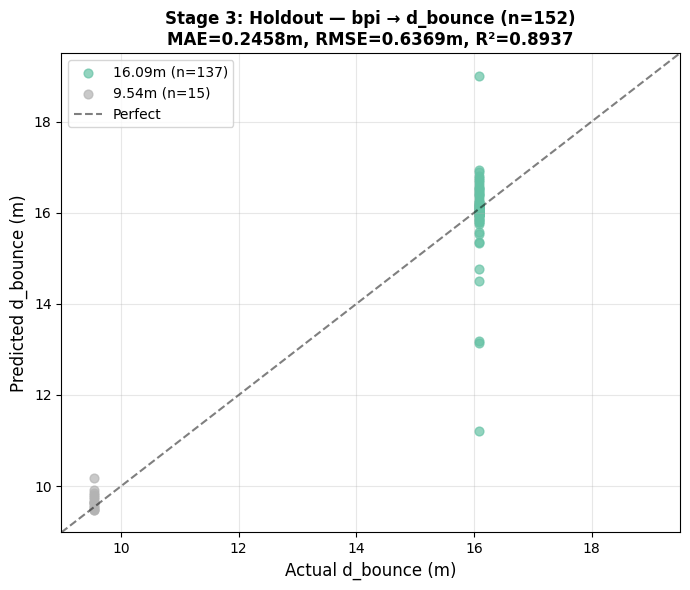

In [49]:
# ==========================================
# STANDALONE: Predicted vs Actual d_bounce
# ==========================================
fig, ax = plt.subplots(figsize=(7, 6))

unique_test_groups = sorted(set(g_test))
colors = plt.cm.Set2(np.linspace(0, 1, len(unique_test_groups)))
group_colors = {g: colors[i] for i, g in enumerate(unique_test_groups)}

for g in unique_test_groups:
    mask = g_test == g
    ax.scatter(db_test[mask], pred_d_bounce[mask],
               s=40, alpha=0.7, label=f'{g} (n={int(mask.sum())})', color=group_colors[g])

lims = [min(db_test.min(), pred_d_bounce.min()) - 0.5,
        max(db_test.max(), pred_d_bounce.max()) + 0.5]
ax.plot(lims, lims, 'k--', lw=1.5, alpha=0.5, label='Perfect')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('Actual d_bounce (m)', fontsize=12)
ax.set_ylabel('Predicted d_bounce (m)', fontsize=12)
ax.set_title(f'Stage 3: Holdout — bpi → d_bounce (n={len(y_test)})\n'
             f'MAE={test_mae:.4f}m, RMSE={test_rmse:.4f}m, R²={test_r2:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Section 8: Save Artifacts

In [50]:
# ==========================================
# SAVE ARTIFACTS
# ==========================================
import joblib

joblib.dump(pred_model, "stage3_nlos_bias_rf.joblib")
print("Saved: stage3_nlos_bias_rf.joblib")

joblib.dump({
    "method": "lnn_embeddings_fp_idx_dhw_rf_regressor",
    "features": f"{FEATURE_DIM} total (64 LNN embeddings + fp_idx + d_hardware)",
    "target": "bounce_path_idx (CIR index, continuous per sample)",
    "inverse": f"d_bounce = d_hardware + (pred_bpi - fp_idx) × {M_PER_IDX}",
    "train_data": "combined correctable only (9.54m + 16.09m)",
    "test_bpi_mae": float(test_bpi_mae),
    "test_mae": float(test_mae),
    "test_rmse": float(test_rmse),
    "test_r2": float(test_r2),
}, "stage3_config.joblib")
print("Saved: stage3_config.joblib")

Saved: stage3_nlos_bias_rf.joblib
Saved: stage3_config.joblib


In [51]:
print("=" * 60)
print("Stage 3 — Summary")
print("=" * 60)
print(f"Method: LNN embeddings + fp_idx + d_hardware → RF Regressor")
print(f"Features: {FEATURE_DIM} total (64 LNN + fp_idx + d_hardware)")
print(f"Target: bounce_path_idx = fp_idx + (d_bounce - d_hardware) / {M_PER_IDX}")
print(f"Inverse: d_bounce = d_hardware + (pred_bpi - fp_idx) × {M_PER_IDX}")
print()
print(f"Data: {len(d_bounce)} combined correctable (9.54m + 16.09m)")
print(f"  Train: {len(X_train)}, Holdout: {len(X_test)}")
print()
print(f"Holdout results:")
print(f"  bpi MAE:     {test_bpi_mae:.4f} idx ({test_bpi_mae*M_PER_IDX:.4f}m)")
print(f"  d_bounce MAE: {test_mae:.4f}m")
print(f"  d_bounce RMSE: {test_rmse:.4f}m")
print(f"  d_bounce R²:  {test_r2:.4f}")
print()
print("Storyline:")
print("  1. Stage 1: Train + validate LOS/NLOS (holdout + OOD)")
print("  2. Stage 2: Train + validate correctable (holdout + OOD)")
print("  3. Stage 3: Train + validate bounce distance (holdout)")
print("  4. test_pipeline: Chain all 3 stages end-to-end")

Stage 3 — Summary
Method: LNN embeddings + fp_idx + d_hardware → RF Regressor
Features: 66 total (64 LNN + fp_idx + d_hardware)
Target: bounce_path_idx = fp_idx + (d_bounce - d_hardware) / 0.3003
Inverse: d_bounce = d_hardware + (pred_bpi - fp_idx) × 0.3003

Data: 506 combined correctable (9.54m + 16.09m)
  Train: 354, Holdout: 152

Holdout results:
  bpi MAE:     0.8185 idx (0.2458m)
  d_bounce MAE: 0.2458m
  d_bounce RMSE: 0.6369m
  d_bounce R²:  0.8937

Storyline:
  1. Stage 1: Train + validate LOS/NLOS (holdout + OOD)
  2. Stage 2: Train + validate correctable (holdout + OOD)
  3. Stage 3: Train + validate bounce distance (holdout)
  4. test_pipeline: Chain all 3 stages end-to-end
